# Week 7 - Dimensionality reduction

Welcome to week 7 of our course. Today, we'll focus on dimensionality reduction. In fact, we're approaching the full monty for being a Data Scientist. In other words, in this notebook, you'll experience a lot of the whole process, including data preparation, dimensionality reduction, exploratory analysis (clustering in this case), model building (classification in this case), and evaluation.

## Part 1a - Covariance, trace, correlation

Let's start with the basics: get insights of the concepts of Covariance, trace and correlation. 

...but first, let's do the usual imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

We will use a well dataset well-known to you, "NYC_taxis_weather_2016_with_dummies.csv". It's amazing the number of things we can do with a single one!... 

In [21]:
f=pd.read_csv("NYC_taxis_weather_2016_with_dummies.csv")

In [22]:
f

,datetime,pickups1,pickups17_lag1,pickups17_lag2,pickups1_lag1,pickups1_lag2,pickups21_lag1,pickups21_lag2,pickups28_lag1,pickups28_lag2,...,fog,rain_drizzle,time_of_day_afternoon,time_of_day_afternoon rush,time_of_day_evening,time_of_day_lunch time,time_of_day_morning,time_of_day_morning rush,time_of_day_night,is_weekend
0,2016-01-01 00:00:00,162,202.0,307.0,109.0,171.0,198.0,306.0,40.0,54.0,...,0,0,0,0,0,0,0,0,1,False
1,2016-01-01 00:15:00,251,394.0,202.0,162.0,109.0,312.0,198.0,29.0,40.0,...,0,0,0,0,0,0,0,0,1,False
2,2016-01-01 00:30:00,310,420.0,394.0,251.0,162.0,699.0,312.0,16.0,29.0,...,0,0,0,0,0,0,0,0,1,False
3,2016-01-01 00:45:00,338,310.0,420.0,310.0,251.0,482.0,699.0,3.0,16.0,...,0,0,0,0,0,0,0,0,1,False
4,2016-01-01 01:00:00,369,403.0,310.0,338.0,310.0,459.0,482.0,2.0,3.0,...,0,0,0,0,0,0,0,0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17467,2016-06-30 22:45:00,316,639.0,624.0,318.0,291.0,406.0,305.0,201.0,189.0,...,0,0,0,0,1,0,0,0,0,False
17468,2016-06-30 23:00:00,299,593.0,639.0,316.0,318.0,347.0,406.0,168.0,201.0,...,0,0,0,0,0,0,0,0,1,False
17469,2016-06-30 23:15:00,283,617.0,593.0,299.0,316.0,252.0,347.0,104.0,168.0,...,0,0,0,0,0,0,0,0,1,False
17470,2016-06-30 23:30:00,276,580.0,617.0,283.0,299.0,246.0,252.0,87.0,104.0,...,0,0,0,0,0,0,0,0,1,False


In [23]:
f['datetime']=pd.to_datetime(f['datetime'], format="%Y-%m-%d %H:%M:%S")
f=f.set_index('datetime')
f['date']=np.array([d.date() for d in f.index])

grouped=list(set(f['date']))  #transforms f['date'], a series of days WITH repetitions, into a set. Then we convert it back to
# a list WITHOUT repititions. To understand this, just check the original value of f['date'], and the output set(f['date'])

days={}
grouped=np.sort(grouped)
for g in grouped:
    day_ts=np.array(f[f.date==g]['pickups1'])
    days[g]=day_ts

d=pd.DataFrame(days)
dt=d.transpose()

In [24]:
print(dt.shape)
dt.head()


(182, 96)


,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
2016-01-01,162,251,310,338,369,319,314,328,346,297,...,101,128,119,102,91,86,96,99,83,113
2016-01-02,79,102,66,89,71,59,52,57,41,21,...,152,180,184,165,169,146,138,132,144,128
2016-01-03,156,128,120,116,108,112,82,62,73,83,...,61,91,81,65,95,71,55,45,51,39
2016-01-04,41,36,23,27,21,22,21,18,18,18,...,180,179,216,167,122,121,113,88,86,73
2016-01-05,81,68,49,62,37,25,29,27,27,29,...,247,237,209,182,182,141,158,115,87,91


### Question 1 - understanding the data

What does <code>dt</code> contain? 

- **Q1:** what does each row represent? 
- **Q2:** what does each column represent? 
- **Q3** why do we have 182 rows, while we had 17472 observations in <code>f</code> ?
- **Q4** why do we have 96 columns?
- **Q5** how values in each cell were obtained?

You should proceed **only after you are sure you understand what <code>dt</code> contains**. Now, check the covariance matrix of <code>dt</code>.


Each row represent one day, and the columns represent each timestamp of the day. We only have 182 rows since the original dataset only consist of 182 days. 


### Question 2 - How do variance and co-variance work?

What does the covariance value mean (e.g. between two variables)? If we get a high covariance, does it mean the variables are somehow related, or is it the opposite? Again, understanding the data is crucial to understand the next steps. 

Check the covariance between the following vectors and answer the following questions: 
- **Q1:** How does the **Variane** of each variable look like? 
- **Q2:** - How does the **Coariane** between variables look like?
- **Q3:** - Comment on the **scale** of the variance of each variable. Why is it different? Does the magnitude tell us something about the data?
- **Q4:** - Comment on the **sign** and the magnitude of the covariance. Does that tell us something?
- **Q5:** - Comment on why **<code>dt</code>** has dimension 96x96


Each fro 


In [37]:
x = [-2.1, -1,  4.3]
y = [3,  1.1,  0.12]
X = np.stack((x, y), axis=0)
print(np.cov(X))
print(np.cov(x, y))
print(np.cov(x))

[[11.71       -4.286     ]
 [-4.286       2.14413333]]
[[11.71       -4.286     ]
 [-4.286       2.14413333]]
11.709999999999999


In [46]:
#We use reshape to be sure that all vectors have the right dimension
# Check the covariance of these vectors
v1=np.array([1,2,3,4,5,6]).reshape(1,-1)
v2=np.array([1,2,3,4,5,6]).reshape(1,-1)
v3=np.array([9,8,7,6,5,4]).reshape(1,-1)
v4=np.array([4,2,6,3,.7,8]).reshape(1,-1)

print(np.var(v1))
print(np.var(v2))
print(np.var(v3))
print(np.var(v4))

print(np.cov(v1, v2))
print(np.cov(v1, v3))
print(np.cov(v1, v4))
print(np.cov(v2, v3))
print(np.cov(v2, v4))
print(np.cov(v3, v4))





2.9166666666666665
2.9166666666666665
2.9166666666666665
5.979166666666668
[[3.5 3.5]
 [3.5 3.5]]
[[ 3.5 -3.5]
 [-3.5  3.5]]
[[3.5   1.31 ]
 [1.31  7.175]]
[[ 3.5 -3.5]
 [-3.5  3.5]]
[[3.5   1.31 ]
 [1.31  7.175]]
[[ 3.5   -1.31 ]
 [-1.31   7.175]]


### Question 3 - How do variance and co-variance work?

Let us now focus only on v1 and v2. 
- **Q1:** Compute the trace of of the covariance matrix between v1 and v2
- **Q2:** What does the trace of the covariance matrix of a dataset mean? The covariance matrix can help you here
- **Q3:** What is the relationship between covariance and correlation? Can you calcolate the correlation beween v1 and v2?
- **Q4:** Can you compute the total variance from **<code>dt.cov()</code>** without analytically (without eccessively relying on prebuilt function)? 

In [26]:
# Q1 here

__R2: ANSWER HERE__

In [27]:
# Q3 Compute the correlation between v1 and v2

In [47]:
dt.cov()  # covariance matrix of the dataframe dt

,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
0,6330.946755,5976.904013,5754.723089,5382.047781,4841.026167,4578.022949,4312.953312,3894.198106,3741.269990,3481.944751,...,-2187.859511,-2052.848218,-2253.866250,-1579.787870,-729.757756,-84.180135,681.633234,1074.153057,1481.830369,1921.969097
1,5976.904013,6117.943446,5746.449123,5410.762340,4945.109738,4663.956014,4415.643616,4005.826361,3892.009289,3635.320442,...,-2331.280189,-2153.495993,-2351.344818,-1709.975381,-843.693583,-286.630077,456.478751,867.232226,1342.165564,1760.218596
2,5754.723089,5746.449123,5875.899854,5399.458290,4960.262917,4662.796218,4403.510959,4067.153118,3956.066541,3674.430939,...,-2629.531176,-2467.885769,-2634.664289,-2054.854320,-1206.776881,-624.685811,131.690395,513.271265,964.905531,1382.191701
3,5382.047781,5410.762340,5399.458290,5284.142098,4778.357264,4502.285380,4266.958047,3946.451460,3817.146864,3542.657459,...,-2710.100237,-2581.072764,-2767.718262,-2203.040040,-1393.984275,-837.573189,-135.805992,205.190942,649.411268,1088.826635
4,4841.026167,4945.109738,4960.262917,4778.357264,4606.220296,4225.370803,3998.591464,3686.824783,3620.465121,3346.160221,...,-2690.756117,-2567.650568,-2680.897122,-2244.260002,-1457.671908,-951.842875,-332.215682,27.727460,447.178617,846.977020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,-84.180135,-286.630077,-624.685811,-837.573189,-951.842875,-988.275818,-1010.351284,-1054.516180,-1045.280554,-972.381215,...,5670.703236,5720.049056,5690.918888,5946.979783,5983.911177,6412.482545,5994.670208,5909.035881,5349.301135,5157.740271
92,681.633234,456.478751,131.690395,-135.805992,-332.215682,-354.614747,-437.847854,-503.950276,-486.114747,-462.712707,...,5197.104972,5223.604547,5189.236932,5487.899490,5611.799830,5994.670208,6238.831067,6005.639609,5510.807905,5396.480875
93,1074.153057,867.232226,513.271265,205.190942,27.727460,-55.338717,-125.540404,-234.980268,-238.011960,-215.933702,...,4942.780584,5013.410722,4962.972436,5331.113229,5513.333192,5909.035881,6005.639609,6425.131929,5788.437132,5724.396454
94,1481.830369,1342.165564,964.905531,649.411268,447.178617,354.018275,285.330460,132.250987,180.824115,127.546961,...,4198.998421,4263.953919,4221.845243,4621.533180,4821.843604,5349.301135,5510.807905,5788.437132,5899.319774,5733.222330


## Part 1b - Eigendecomposition

### Question 1 - Eigenvalue decomposition

Before doing eigenvalue decomposition, let us recap some theory:
- **Q1:** Why do we need eigenvalue decomposition in the first place? 
- **Q2:** Based on the content of the slides, to which matrix we need to apply eigenvalue decomposition?
- **Q3:** How many Eigenvalues should we expect in total?


We can extract the eigenvalues and eigenvectors of a matrix using the function
> eigenValues, eigenVectors = np.linalg.eig(MATRIX)

After answering the questions above, proceed by replacint MATRIX with the right variable. 

In [49]:
eigenValues, eigenVectors = np.linalg.eig(dt.cov())

__R1: ANSWER HERE__.

__R2: ANSWER HERE__.

__R3: ANSWER HERE__.

In [ ]:
# plot eigenvalues
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(eigenValues)+1), eigenValues, 'o-')
plt.title('Eigenvalues of the covariance matrix')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

### Question 2 - Feasibility constraints of the projected space

- **Q1:** The slides say that "As the eigenvectors are orthogonal to each other, the principal components will be uncorrelated." Can you confirm that on the data?

**Note:** Two vectors are orthogonal to each other when their dot product is 0. See the example here for inspiration: https://www.geeksforgeeks.org/orthogonal-and-orthonormal-vectors-in-linear-algebra/



In [ ]:
# Q1 here

- **Q2:** The slides also say that "constrain |u1| such that $u_1^Tu_1=1$"

Can you confirm this on the data (notice that u1 is simply the first eigenvector)

In [ ]:
# Q2 here

- **Q3:** look at the numerical value of the first Eigenvalue. What does it mean? 
- **Q4:** Sum the eigenvalues. What does the sum look like? Did you see this number before? Does it have any meaning? 


In [ ]:
# Q3 and Q4 here

### Question 3 - Understanding the PCA

We can plot the cumulatice sum of the EiveValues. this is the cumulative sum of the variance explained by each eigenvector - or Pricipal Component. 

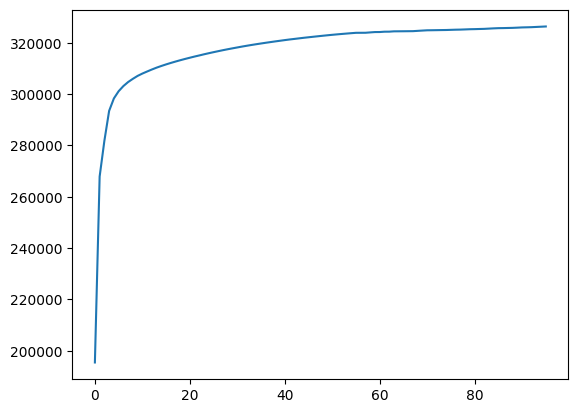

In [ ]:
plt.plot(np.cumsum(eigenValues))
plt.show()

Can you explain a bit this graph? 

- **Q1** What does it tell us? 
- **Q2** How does this plot help deciding how many Principal Components we need to use? 

__R1:  ANSWER HERE.__

__R21:  ANSWER HERE__

## Part 2a - PCA class in sklearn

As always happens in sklearn, and a lot of python packages, there are classes/objects available that perform very complex tasks. In this case, the PCA class helps you do practically everything you need in terms of Principal Components Analsysis. Let's get it running...

In [ ]:
from sklearn import decomposition

In [ ]:
pca=decomposition.PCA()

As with the other models in sklearn, you estimate it with the fit function

In [ ]:
pca.fit(dt)

PCA()

Notice that you're supposed to tell how many components it estimates with the parameter "n_components". If you don't say anything, it estimates all of them. 

- **Q1** How many components is 'all of them'? 


A very useful functionality of the PCA object is that it provides the explained variance ratio, by each eigenvector, in decreasing order

In [ ]:
np.sum(pca.explained_variance_ratio_)

np.float64(1.0000000000000002)

The typical question is _how many vectors do I need to use, to cover X% of the variance?_

...and the typical answer is by creating a cumulative graph (similar to a cumulative distribution function, or CDF).

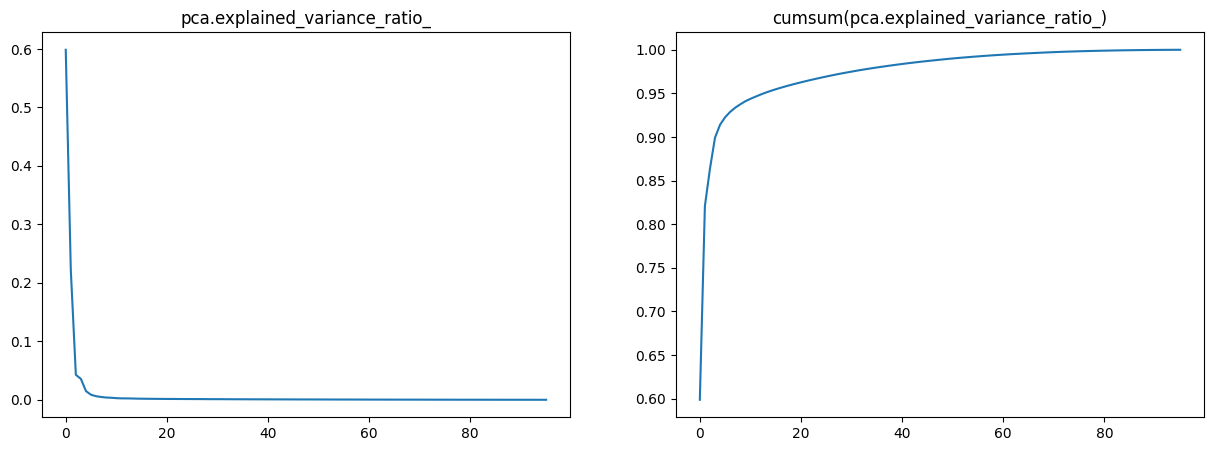

In [ ]:
expl=pca.explained_variance_ratio_

fig=plt.figure(figsize=(15, 5))
ax1=fig.add_subplot(121)
ax1.plot(expl)
plt.title("pca.explained_variance_ratio_")

ax2=fig.add_subplot(122)
plt.plot(np.cumsum(expl))
plt.title("cumsum(pca.explained_variance_ratio_)")
plt.show()

Note that the plot above is very similar to the one obtained using eigenvalue decomposition, but it is between zero and one. This is because it is normalized for observability. 

Another typical thing to do is to plot the eigenvectors themselves. 

The field ```pca.components_``` in the PCA object provides the eigenvectors:



[[-0.09060596 -0.09523997 -0.10180615 ...  0.11517392  0.09379586
   0.08181419]
 [ 0.21757189  0.21650594  0.20529452 ...  0.18261751  0.18837964
   0.20061803]
 [ 0.17963923  0.15684686  0.13723983 ...  0.22654331  0.21618476
   0.23152708]
 ...
 [-0.03728535 -0.00558026  0.01202    ... -0.03817095  0.06210976
   0.00283398]
 [ 0.01283103 -0.05772351 -0.02526685 ... -0.01994406 -0.01358793
   0.00463572]
 [ 0.07195712 -0.05097444  0.06526331 ...  0.04506492 -0.03414787
  -0.02917291]]


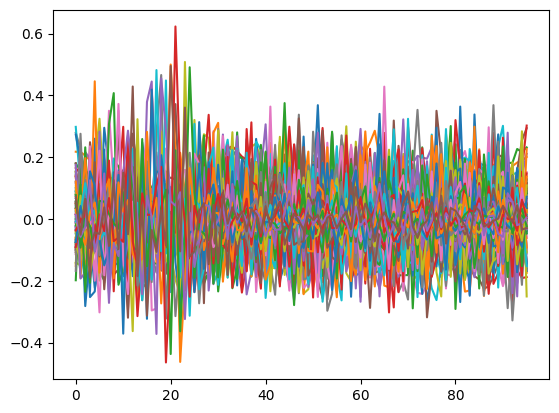

In [ ]:
# This function can be used to call eigenvalues from pca
print(pca.components_)

# We can plot them one by one
for eigenvector in pca.components_:
    plt.plot(range(len(eigenvector)), eigenvector)

plt.show()

### Questions: 

Now that you have seen how to compute PCA with SKLearn, let us use it properly.

- **Q2** How many vectors do you need, in order to explain 80% of the variance?


In [ ]:
# Q2 here

- **Q3** Can you plot the eigenvectors that explain 80% of the variance?


In [ ]:
# Q3 here

VERY interesting result, isn't it? What's your interpretation?

## Part 2b - Correlation vs Covariance in PCA

PCA leads to different results, depending on whether it applies eigendecomposition to the correlation or the covariance matrix.

Above, we used covariance (default), let's now use correlation

In [ ]:
pca=decomposition.PCA()

In practice, you just need to _standardize_ the data. In other words, each column should be removed its mean and divided by its standard deviation. Can you do it?

In [ ]:
# standardize dt data 

Let's estimate the pca model (same as before, you must use <code> pca.fit(your_data) </code>)

In [ ]:
# apply the PCA to the standardized data set

Let's plot the cdf

In [ ]:
# Plot the CDF

Look into the explained variance values. Compare them with the above version.

Plot the first two eigenvectors. Compare with above

In [ ]:
# Plot the Eigenvectors

## Part 3 - PCA in clustering and classification

Ok, you learned about a technique that represents the data in a different way. How can this help you?

One easy thing you can now do right away is to visualize the first 2 or 3 eigen vectors. With 2, you only need a 2D plot, so let's do it!

Estimate a new pca model, using the dt dataset above, with ONLY 2 components


In [ ]:
pca_new=decomposition.PCA(n_components=2)
pca_new.fit(dt)

PCA(n_components=2)

Now, the true reason for all of this! For each data point, let's re-represent it with ONLY 2 dimensions... 


In [ ]:
X_reduced=pca_new.transform(dt)

- **Q1:** Can you check the dimension/shape of the original data dt and the new X_reduced?
- **Q2:** Explain what happened?


In [ ]:
# Q1 and Q2 here

Cool, now let's plot the projected data ```X_reduced```, where the x axis corresponds to the first dimension (or Firzt principal component), and the y axis to the second one.

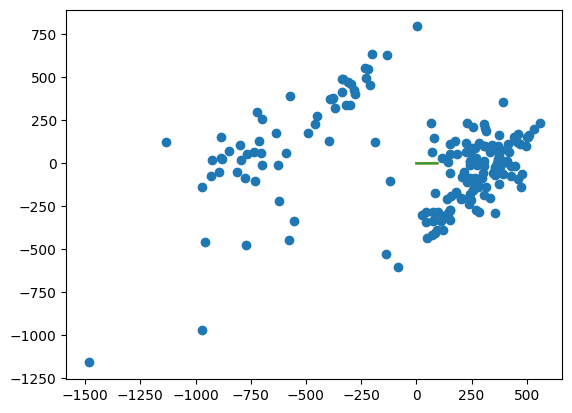

In [ ]:
# Plot X_reduced here using a scatter plot

WOW! There are clearly two clusters... think of the 2 eigenvectors we visualized above. What does this mean? Notice that each data point corresponds to the full pattern of one day of taxi data...

-------

### Clusetring

When we visualize clearly data into clusters like above, we tipically ask ourselves, what's so special about each cluster.

For example, would it be that there are "weekend" patterns, and "weekday" patterns? The best way to find out is to plot it. For example using colors (red for weekend, blue for weekday)

In order to do that visualization, we need quite some data preparation. For example, we need to bring that info ("is_weekend") into the dataset...

In [ ]:
dt_reduced=pd.DataFrame(X_reduced)  #X_reduced is still a numpy array, let's create a Pandas DataFrame

In [ ]:
import warnings
warnings.filterwarnings('ignore') # To ignore warnings

fnew=dt_reduced[:]  #Let's make a copy, just in case...
fnew['date']=dt.index   #bringing the original dates to the data frame

We need to add the other info (let's add weather data too, it will be useful later)

In [ ]:
f_merged=pd.merge(f[['temp', 'prcp', 'fog', 'rain_drizzle', 'is_weekend', 'date']], fnew,  on='date', how='inner').drop_duplicates()

Let's index the lines with date

In [ ]:
f_merged=f_merged.set_index('date')

Now, the scatter plot with colors. Take a look at this code. What does it do?

In [ ]:
def assign_color(x):
    if x==True:
        return 'red'
    else:
        return 'blue'
colours=[assign_color(x) for x in f_merged['is_weekend']]

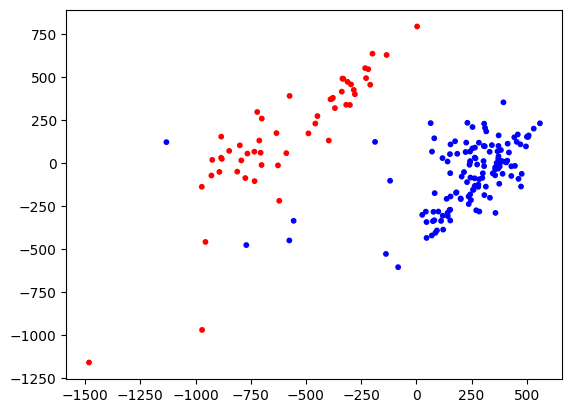

In [ ]:
plt.scatter(f_merged[0], f_merged[1], c=colours, s=10)
plt.show()

--------------------

The natural next step is to see if - not one variable alone - multiple variables can predict the cluster. If yes, then there is some strong correlation, and that would be helpful for prediction (e.g. using weather forecast to predict demand on the following day). 


So we want to build a classifier that receives, as input, the available information about a given day (weather, is_weekend...), and produces, as output, the class (in which of the 2 clusters that day belongs to).

Let's start by creating the classes (i.e. the clusters)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
K=2
k=KMeans(K)

In [ ]:
k.fit(dt_reduced)

KMeans(n_clusters=2)

Let's visualize it

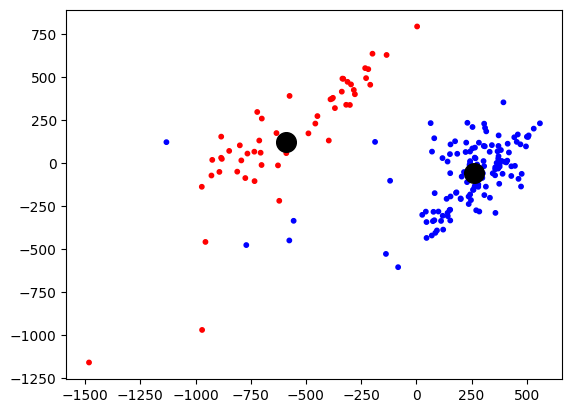

In [ ]:
plt.scatter(f_merged[0], f_merged[1], c=colours, s=10);

plt.scatter(k.cluster_centers_[:, 0], k.cluster_centers_[:, 1], s=200, c='black')
plt.show()

So, let's create a new column ("cluster"), that has the "class"

In [ ]:
dt_reduced['cluster']=k.fit_predict(dt_reduced)

In [ ]:
dt_reduced

,0,1,cluster
0,-1131.949678,123.521205,0
1,-620.945002,-217.757806,0
2,-955.192614,-457.007692,0
3,-137.784307,-526.846842,1
4,46.074722,-433.773559,1
...,...,...,...
177,-633.611068,176.276290,0
178,82.907241,-173.147971,1
179,154.804108,-192.463951,1
180,240.748084,-8.234993,1


Again, we need to add weather and date information. 

**TIP:** You had to do this operation last week for 'clustering'. So, we simply re-do it here

In [ ]:
fnew=dt_reduced[:]
fnew=fnew.set_index(dt.index)
fnew.index.names = ['date']
fnew=fnew.reset_index()

In [ ]:
f_days=f.groupby('date').mean()
f_days=f_days.reset_index()

In [ ]:
f_merged=pd.merge(f_days[['temp', 'prcp', 'fog', 'rain_drizzle', 'is_weekend', 'date']], fnew,  on='date', how='right')

In [ ]:
f_merged=f_merged.set_index('date')

In [ ]:
del f_merged[0]
del f_merged[1]
f_merged

,temp,prcp,fog,rain_drizzle,is_weekend,cluster
date,,,,,,
2016-01-01,40.4,0.03,0.0,0.0,0.0,0
2016-01-02,35.8,0.00,0.0,0.0,1.0,0
2016-01-03,38.4,0.00,0.0,0.0,1.0,0
2016-01-04,30.8,0.00,0.0,0.0,0.0,1
2016-01-05,18.4,0.00,0.0,0.0,0.0,1
...,...,...,...,...,...,...
2016-06-26,74.7,0.00,0.0,0.0,1.0,0
2016-06-27,74.3,0.00,0.0,0.0,0.0,1
2016-06-28,71.1,0.54,0.0,1.0,0.0,1


### Classification

Now, you have everything to create your classifier. Just pick your favourite one and run it! We try with LogisticRegression

**NOTE**: for this part, you can get inspired from the notebook on 'classification' and replace the data with the new data set

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [ ]:
split=int(len(f_merged)*2/3)
trainset=f_merged[:split]
testset=f_merged[split:]

In [ ]:
x=trainset[['temp', 'prcp', 'fog', 'rain_drizzle', 'is_weekend']]
y=trainset['cluster']
x_new=testset[['temp', 'prcp', 'fog', 'rain_drizzle', 'is_weekend']]
y_new=testset['cluster']


In [ ]:
# Use here any model to fit the data. You can use logistic regression or something else

Don't forget to evaluate... check the "score" and the confusion matrix.

----------

## Appendix (strongly recommended)- Multidimensional scaling (MDS)

Let's now try a different technique, multidimensional scaling, or MDS. It's in another part of sklearn:

In [ ]:
from sklearn.manifold import MDS

As usual, let's create the object

In [ ]:
mds=MDS() #by default it maps to 2D (if you want another option, just use the parameter n_components)

We will use the original data from above, already in the day time series format. So, the object dt. 

In [ ]:
mds.fit(dt)

MDS()

In MDS, the new data is said to be "embedded" in a (normally) 2D space. The attribute that has the corresponding data is called embedding_.

Try
> mds.embedding_

The output is a list of 2D datapoints. Can you visualize it?

In [ ]:
mds.embedding_

array([[ -166.38673416, -1285.36329742],
       [  426.67403841,  -630.93861318],
       [  574.106952  ,  -919.13237206],
       [  581.34363426,  -121.79238419],
       [  481.45646439,    50.87294509],
       [  340.23802594,    73.95170398],
       [  152.4393684 ,   161.32492452],
       [   28.28623511,   103.87428358],
       [ -147.33990943,  -514.31970256],
       [  267.18826766,  -995.30844966],
       [  459.24578551,   102.12511935],
       [  203.92122673,   196.72523286],
       [  128.39437803,   419.28942262],
       [    7.08504251,   436.07952582],
       [  -84.64223124,   104.23085659],
       [ -213.16795741,  -490.62520499],
       [   56.62172481,  -923.09450382],
       [  542.79676471,  -540.24961697],
       [  343.50818482,   424.50074727],
       [  151.31971869,   351.58031373],
       [    4.11444229,   385.90724427],
       [  -93.61163762,   143.45400353],
       [ 1456.03620596, -1456.75106035],
       [ 1156.02539524,  -892.65932091],
       [  659.76

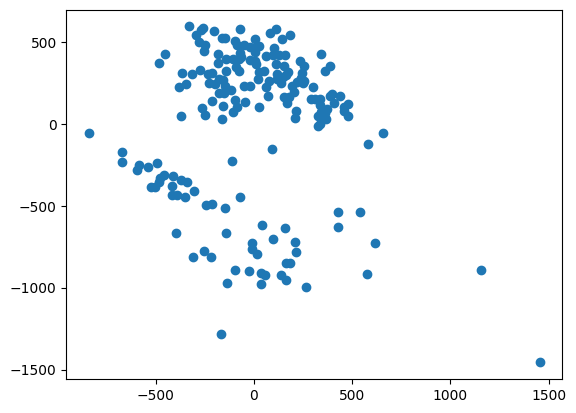

In [ ]:
plt.scatter(mds.embedding_[:,0], mds.embedding_[:,1])
plt.show()

Is it the same as above? Compare it with the PCA results...